In [79]:
# ============================================================
# STEP 11 — IMPORT MODEL
# ============================================================

from sklearn.ensemble import RandomForestClassifier

In [80]:
# ============================================================
# STEP 12 — SELECT FEATURES
# ============================================================

X = rfm[
    ['Recency', 'Frequency', 'Monetary']
]


y = rfm['Churn']

In [81]:
# ============================================================
# STEP 13 — TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

In [82]:
# ============================================================
# STEP 14 — TRAIN RANDOM FOREST MODEL
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)

In [83]:
# ============================================================
# STEP 15 — PREDICT CHURN
# ============================================================

churn_predictions = rf_model.predict(
    X_test
)

In [84]:
# ============================================================
# STEP 16 — EVALUATE CHURN MODEL
# ============================================================

accuracy = accuracy_score(
    y_test,
    churn_predictions
)

print('Accuracy:', accuracy)

print(
    classification_report(
        y_test,
        churn_predictions
    )
)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       571
           1       1.00      1.00      1.00       292

    accuracy                           1.00       863
   macro avg       1.00      1.00      1.00       863
weighted avg       1.00      1.00      1.00       863



In [85]:
# ============================================================
# STEP 17 — FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

     Feature  Importance
0    Recency    0.886124
1  Frequency    0.058765
2   Monetary    0.055111


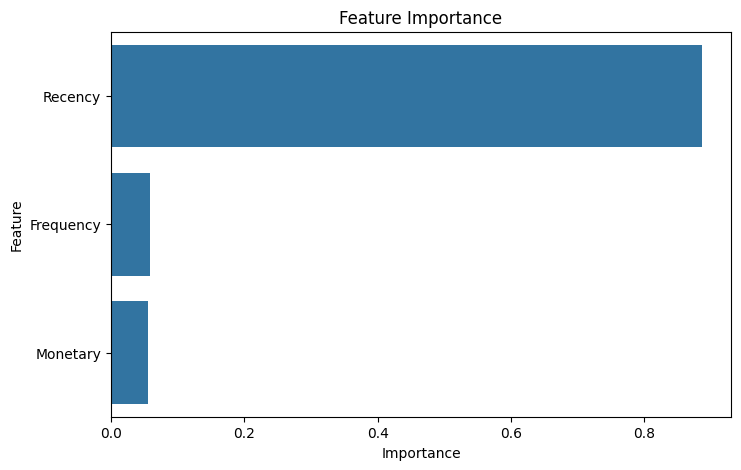

In [86]:
# ============================================================
# STEP 18 — VISUALIZE FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')

plt.show()

In [87]:
# ============================================================
# STEP 19 — SAVE MODELS
# ============================================================

import joblib

# Save forecasting model
joblib.dump(
    xgb_model,
    'xgboost_forecast_model.pkl'
)

# Save churn model
joblib.dump(
    rf_model,
    'rf_churn_model.pkl'
)

print('Models Saved Successfully')

Models Saved Successfully


In [88]:
! pip install mlflow

     ---------------------------------------- 0.0/40.6 kB ? eta -:--:--
     ---------------------------------------- 40.6/40.6 kB 1.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/26.7 MB ? eta -:--:--
   ---------------------------------------- 0.2/26.7 MB 11.6 MB/s eta 0:00:03
   - -------------------------------------- 0.7/26.7 MB 8.9 MB/s eta 0:00:03
   - -------------------------------------- 1.1/26.7 MB 8.4 MB/s eta 0:00:04
   -- ------------------------------------- 1.8/26.7 MB 9.8 MB/s eta 0:00:03
   --- ------------------------------------ 2.2/26.7 MB 10.1 MB/s eta 0:00:03
   ---- ----------------------------------- 2.8/26.7 MB 11.3 MB/s eta 0:00:03
   ----- ---------------------------------- 3.4/26.7 MB 11.5 MB/s eta 0:00:03
   ----- ---------------------------------- 4.0/26.7 MB 10.5 MB/s eta 0:00:03
   ------ --------------------------------- 4.2/26.7 MB 10.8 MB/s eta 0:00:03
   ------ --------------------------------- 4.5/26.7 MB 10.2 MB/s eta 0:00:03
 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.33.0 requires protobuf<5,>=3.20, but you have protobuf 5.29.6 which is incompatible.
tensorflow-intel 2.13.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 5.29.6 which is incompatible.
tensorflow-intel 2.13.0 requires typing-extensions<4.6.0,>=3.6.6, but you have typing-extensions 4.12.2 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [89]:
# ============================================================
# STEP 21 — TRACK EXPERIMENTS
# ============================================================

import mlflow

with mlflow.start_run():

    mlflow.log_param(
        'model_type',
        'XGBoost'
    )

    mlflow.log_metric(
        'MAE',
        mae
    )

    mlflow.log_metric(
        'RMSE',
        rmse
    )

print('MLflow Tracking Completed')

MLflow Tracking Completed


In [90]:
# ============================================================
# STEP 22 — CREATE SAMPLE INPUT
# ============================================================

sample_input = pd.DataFrame({
    'Year': [2025],
    'Month': [5],
    'Day': [20],
    'Weekday': [1],
    'lag_1': [12000],
    'lag_7': [11500],
    'rolling_mean_7': [11800]
})

prediction = xgb_model.predict(
    sample_input
)

print('Predicted Sales:', prediction)

Predicted Sales: [288.5313]


In [91]:
# ============================================================
# STEP 23 — SAVE FINAL DATASETS
# ============================================================

rfm.to_csv(
    'final_customer_data.csv',
    index=False
)


daily_sales.to_csv(
    'final_sales_data.csv',
    index=False
)

print('Final Datasets Saved')

Final Datasets Saved


In [ ]:
Phase 4 — Dashboard & Deployment

In [95]:
# ============================================================
# STEP 1 — INSTALL REQUIRED PACKAGES
# ============================================================

# Install Streamlit dashboard framework
#! pip install streamlit

# Install Plotly interactive charts
#! pip install plotly

# Install FastAPI
#!pip install fastapi uvicorn


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
